In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [70]:
# Load Data
df_23min = pd.read_csv('./Data/D76_24min.csv', sep=';')

In [71]:
# Calculate base fog (minimum density) for each dataset
base_fog_23min = df_23min["Density"].min()

# Define Point A as 0.1D above base fog
point_A_23min_density = base_fog_23min + 0.1

# Find the corresponding LogE values for Point A
point_A_23min_LogE = np.interp(point_A_23min_density, df_23min["Density"], df_23min["LogE"])
point_A_23min = { "LogE": point_A_23min_LogE.round(3), "Density": point_A_23min_density }

# Define LogE value for Aim Point B (1.30 units above base LogE)
logE_B_23min = point_A_23min["LogE"] + 1.30

# Calculate the actual density for Point B (1.30 units above Point A)
aim_B_23min_density = np.interp(logE_B_23min, df_23min["LogE"], df_23min["Density"])
aim_B_23min = { "LogE": logE_B_23min, "Density": aim_B_23min_density.round(3) }

# Calculate the expected density for Point B (0.80 ± 0.05 above Point A)
expected_density_B_23min = point_A_23min["Density"] + 0.80

# Calculate the LogE value for the expected density points
expected_B_23min_LogE = np.interp(expected_density_B_23min, df_23min["Density"], df_23min["LogE"])
expected_B_23min = { "LogE": expected_B_23min_LogE.round(3), "Density": expected_density_B_23min }

# Check if B is within the expected range
B_in_range_23min = expected_B_23min["Density"] >= (expected_density_B_23min - 0.05) and expected_B_23min["Density"] <= (expected_density_B_23min + 0.05)

# If B is in range, calculate ISO
ISO_23min = 800 / (10**point_A_23min["LogE"]) if B_in_range_23min else None

# Print results
# Print Point A values
print(f"Point A for D76_23min: LogE = {point_A_23min['LogE']}, Density = {point_A_23min['Density']}")

# Print Point B values
print(f"Point B for D76_23min: LogE = {aim_B_23min['LogE']}, Density = {aim_B_23min['Density']}")

# Print expected Point B values
print(f"Expected Point B for D76_23min: LogE = {expected_B_23min['LogE']}, Density = {expected_B_23min['Density']}")

print(f"Is Point B in range for D76_23min? {'Yes' if B_in_range_23min else 'No'}")
if B_in_range_23min:
    print(f"Calculated ISO for D76_23min: {ISO_23min:.2f}")

Point A for D76_23min: LogE = 0.29, Density = 0.47
Point B for D76_23min: LogE = 1.59, Density = 1.301
Expected Point B for D76_23min: LogE = 1.54, Density = 1.27
Is Point B in range for D76_23min? Yes
Calculated ISO for D76_23min: 410.29


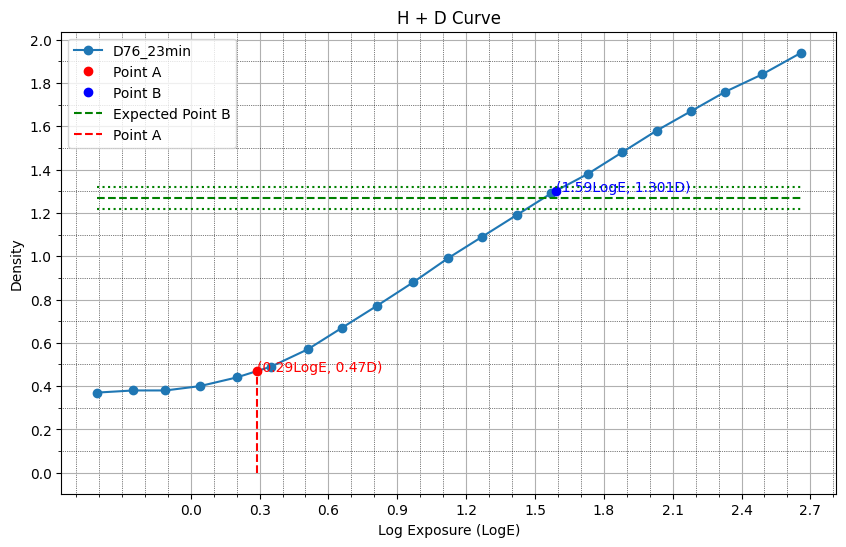

In [72]:
plt.figure(figsize=(10, 6))

# Define major ticks 0.3 for x-axis and 0.2 for y-axis
plt.xticks(np.arange(0, 4, 0.3))
plt.yticks(np.arange(0, 3, 0.2))

# Define minor ticks 0.1 for x-axis and 0.1 for y-axis
plt.minorticks_on()
plt.gca().xaxis.set_minor_locator(plt.MultipleLocator(0.1))
plt.gca().yaxis.set_minor_locator(plt.MultipleLocator(0.1))

# Set grid to be displayed on minor ticks
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='black')



# Plot the H and D curves
plt.plot(df_23min["LogE"], df_23min["Density"], marker='o', linestyle='-', label="D76_23min")

# Mark Points A and B on the plot
plt.plot(point_A_23min["LogE"], point_A_23min["Density"], marker='o', linestyle='', color='red', label="Point A")
plt.plot(aim_B_23min["LogE"], aim_B_23min["Density"], marker='o', linestyle='', color='blue', label="Point B")

plt.text(aim_B_23min["LogE"], aim_B_23min["Density"], f"({aim_B_23min["LogE"]}LogE, {aim_B_23min["Density"]}D)", color='blue')

# Draw horizontal line to expected Point B density over the full x-axis range
plt.hlines(expected_density_B_23min, df_23min["LogE"].min(), df_23min["LogE"].max(), colors='green', linestyles='dashed', label="Expected Point B")
# +/- 0.05 density range over the full x-axis range
plt.hlines(expected_density_B_23min + 0.05, df_23min["LogE"].min(), df_23min["LogE"].max(), colors='green', linestyles='dotted')
plt.hlines(expected_density_B_23min - 0.05, df_23min["LogE"].min(), df_23min["LogE"].max(), colors='green', linestyles='dotted')

# Draw vertical line to Point A density and show the value
plt.vlines(point_A_23min["LogE"], 0, point_A_23min["Density"], colors='red', linestyles='dashed', label="Point A")
plt.text(point_A_23min["LogE"], point_A_23min["Density"], f"({point_A_23min['LogE']}LogE, {point_A_23min['Density']}D)", color='red')

# Labels and title
plt.xlabel("Log Exposure (LogE)")
plt.ylabel("Density")
plt.title("H + D Curve")
plt.legend()
plt.grid(True)

# Show the plot
plt.show()
